# CNN-MagSpin: CNN-Based Classifier for Automated Identification of Magnetic States in Spin Dynamics Simulations

In this project, we  aim to present an automated deep learning model that employs an EfficientNetV1B0 Convolutional Neural Network to classify nine distinct magnetic states, including both FM and, for the first time, AFM spin textures.

This notebook provides a complete workflow for building,  training and evaluating a Convolutional Neural Network (CNN) model.  
The main objectives are as follows:

1. **Load** the training and evaluation dataset.
2. **Build and compile** the CNN architectures (Nine CNNs).  
3. **Display** a detailed summary of the model structure.  
4. **Train** the model on the prepared dataset.  
5. **Save and visualize** the training history.  
6. **Evaluate** the model performance on the test set.

### Library Imports

In [ ]:
import sys
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Model
from keras import models
import time
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from tensorflow.keras.models import load_model
from tqdm import trange
import tensorflow as tf
import pandas as pd
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import cv2
from keras.preprocessing import image
from os import listdir
from tensorflow.keras.optimizers import SGD
from os.path import isfile, join
from tensorflow.keras import layers


### Data Loading and Preprocessing

In [ ]:
path="./Dataset/"
train_data_dir = path+'train/'
validation_data_dir = path+'val/'

train_datagen = ImageDataGenerator()
validation_datagen = ImageDataGenerator()

epochs=50
batch_size = 32
img_rows, img_cols=224,224
train_generator = train_datagen.flow_from_directory(
          train_data_dir,
          target_size=(img_rows, img_cols),
          batch_size=batch_size,
          class_mode='categorical')


validation_generator = validation_datagen.flow_from_directory(
          validation_data_dir,
          target_size=(img_rows, img_cols),
          batch_size=batch_size,
          class_mode='categorical')

Found 4188 images belonging to 9 classes.
Found 862 images belonging to 9 classes.


### CNN Architcture
This code imports and builds several CNN architictures. Supported architectures are: EfficientNetV1B0, EfficientNetV1B1, MobileNet, ResNet50, Xception, MobileNetV2, DenseNet121, VGG19, ResNet101, InceptionResNetV2, and MobileNetV3Small.
To switch architectures, only change the model import and the constructor line:

#### 1) Import the desired backbone
```from tensorflow.keras.applications import EfficientNetB0```  # e.g., change to ResNet50, Xception, etc.

#### 2) Instantiate the backbone
``` model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_rows, img_cols, 3)) ```
e.g., model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_rows, img_cols, 3))


In [ ]:

from tensorflow.keras.applications import EfficientNetB0  #You can replace EfficientNetB0 with another CNN architecture

def get_model():

  img_rows, img_cols = 224,224
  model = Sequential()

#You can replace EfficientNetB0 with another CNN architecture
  model = EfficientNetB0(weights='imagenet', include_top = False,  input_shape = (img_rows, img_cols, 3))
  print(len(model.layers))

  for layer in model.layers:
      layer.trainable = True


  top_model =model.output

  top_model = GlobalAveragePooling2D()(top_model)

  output = Dense(9,activation='softmax')(top_model)
  model = Model(inputs = model.input, outputs = output)

  model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

  return model



### Model Architicture Summary

In [ ]:
model =  get_model()
model.summary()

238


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,061,100 (15.49 MB)

 Trainable params: 4,019,077 (15.33 MB)

 Non-trainable params: 42,023 (164.16 KB)

### Model Training

In [ ]:
#This is with time
import time
import json
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, EarlyStopping

###################################
x = "EfficientNetB0" # Name of the trained classifier and the directory containing all saved model checkpoints, including each model’s accuracy.
model_dir = './models/' + x + '/'
history_path = model_dir + 'history.json'
filepath = model_dir + x + '-epoch{epoch:02d}-acc{val_accuracy:.3f}.keras'
###################################

# Timing Callback
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.start_time)

# Instantiate callbacks
time_callback = TimeHistory()

checkpoint = ModelCheckpoint(
    filepath,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0,
    patience=10,
    verbose=1,
    restore_best_weights=True
)

callbacks = [earlystop, checkpoint, time_callback]

# Fit model
history = model.fit(
    train_generator,
    epochs=epochs,
    callbacks=callbacks,
    batch_size=batch_size,
    validation_data=validation_generator,
    shuffle=True
)

# Save history and timing
history_dict = history.history
history_dict['epoch_times'] = time_callback.epoch_times

with open(history_path, 'w') as f:
    json.dump(history_dict, f)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.8248 - loss: 0.5354
Epoch 1: val_accuracy improved from -inf to 0.84571, saving model to /content/drive/My Drive/Colab Notebooks/ML-Amal/models/ EfficientNetB0-3/ EfficientNetB0-3-epoch01-acc0.846.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 194s 852ms/step - accuracy: 0.8254 - loss: 0.5335 - val_accuracy: 0.8457 - val_loss: 0.6334
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.9767 - loss: 0.0993
Epoch 2: val_accuracy improved from 0.84571 to 0.95244, saving model to /content/drive/My Drive/Colab Notebooks/ML-Amal/models/ EfficientNetB0-3/ EfficientNetB0-3-epoch02-acc0.952.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 392ms/step - accuracy: 0.9767 - loss: 0.0992 - val_accuracy: 0.9524 - val_loss: 0.1353
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9774 - loss: 0.0799
Epoch 3: val_accuracy improved from 0.95244 to 0.97796, saving model to /content/drive/My Drive/Colab Notebooks/ML-Amal/model

### Save Training History for Future Visualization

In [ ]:
#Save Training History for Future Visualization
import json
# Save history to JSON
with open(home_path+'models/'+x+'/history.json', 'w') as f:
    json.dump(history.history, f)





### Model Evaluation on Test Set

In [ ]:
# Loading the test set
path_test="./Dataset/test/"

test_datagen = ImageDataGenerator()
img_rows, img_cols=224,224
test_generator = test_datagen.flow_from_directory(
        path_test,
        target_size=(img_rows, img_cols),
        class_mode='categorical')
classes=test_generator.class_indices
# Fetching x_test, y_test variables from test.
test_generator.reset()
x_test, y_test = next(test_generator)
for i in range(len(test_generator)-1):
    img, label = next(test_generator)
    x_test = np.append(x_test, img, axis=0 )
    y_test = np.append(y_test, label, axis=0)

Found 858 images belonging to 9 classes.


27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 289ms/step
**********************Classification Report ******************
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       102
           1       0.99      0.98      0.99       102
           2       0.99      1.00      1.00       102
           3       1.00      0.97      0.98       100
           4       0.98      0.97      0.98       102
           5       1.00      0.99      1.00       102
           6       1.00      1.00      1.00       102
           7       0.98      1.00      0.99       102
           8       1.00      1.00      1.00        44

    accuracy                           0.99       858
   macro avg       0.99      0.99      0.99       858
weighted avg       0.99      0.99      0.99       858


**************************Confusion Matrix********************


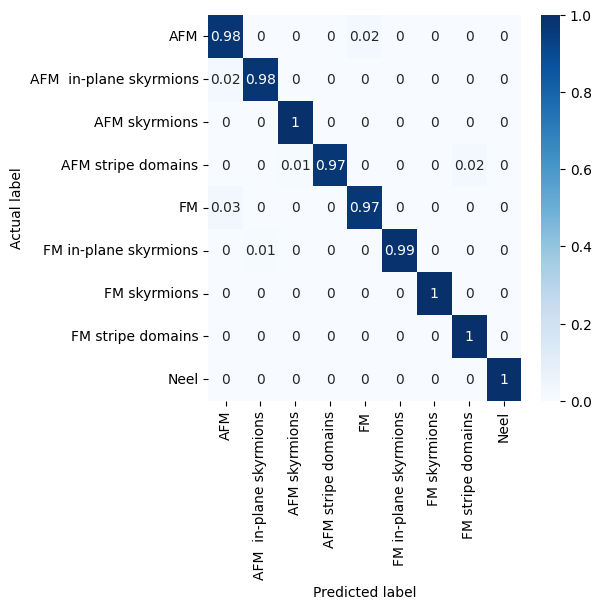

[[100   0   0   0   2   0   0   0   0]
 [  2 100   0   0   0   0   0   0   0]
 [  0   0 102   0   0   0   0   0   0]
 [  0   0   1  97   0   0   0   2   0]
 [  3   0   0   0  99   0   0   0   0]
 [  0   1   0   0   0 101   0   0   0]
 [  0   0   0   0   0   0 102   0   0]
 [  0   0   0   0   0   0   0 102   0]
 [  0   0   0   0   0   0   0   0  44]]


<Figure size 600x600 with 0 Axes>

In [ ]:
# Classification Report and Confusion Matrix
model_name="EfficientNetB0.keras"  # Name of your trained model for evaluation over the test set
model_path="./trainedModels/"+model_name  # This is the default path; change it to match your model’s location.
model= load_model(model_path)
model.load_weights(model_path)

nb_test_samples = len(x_test)
test_generator.reset()

y_pred=model.predict(x_test)


Y_pred=(np.argmax(y_pred,axis=1))
y_test=(np.argmax(y_test,axis=1))


print("**********************Classification Report ******************")
print(classification_report(y_test, Y_pred))
print()

print ("**************************Confusion Matrix********************")
con_mat = tf.math.confusion_matrix(labels=y_test, predictions=Y_pred).numpy()

con_mat_norm_per = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)


con_mat_df_per = pd.DataFrame(con_mat_norm_per,
                         index = classes,
                         columns = classes)


figure = plt.figure(figsize=(6, 6))
sns.heatmap(con_mat_df_per, annot=True,cmap=plt.cm.Blues)

plt.tight_layout()
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

figure = plt.figure(figsize=(6, 6))

print(con_mat)
